# **1. Data Preperation**

In [1]:
import pandas as pd
import numpy as np
import random

df = pd.read_csv("malicious_phish.csv")
df.head()

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement


In [2]:
print(df.shape)
print(df.columns)
print(df['type'].value_counts())

(651191, 2)
Index(['url', 'type'], dtype='object')
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


In [3]:
# data cleaning
df = df.dropna(subset=["url", "type"])

df["url"] = df["url"].astype(str).str.strip().str.lower()
df["type"] = df["type"].astype(str).str.strip().str.lower()

df = df[df["url"] != ""]
df = df.drop_duplicates(subset=["url"])

print("Shape after cleaning:", df.shape)

Shape after cleaning: (641053, 2)


In [4]:
# turn it into a binary classification problem
def to_binary_label(x):
  if x == "benign":
    return "benign"
  else:
    return "malicious"

df["binary_type"] = df["type"].apply(to_binary_label)

class_counts = df["binary_type"].value_counts()
print(class_counts)
df.head()

binary_type
benign       428059
malicious    212994
Name: count, dtype: int64


,url,type,binary_type
0,br-icloud.com.br,phishing,malicious
1,mp3raid.com/music/krizz_kaliko.html,benign,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement,malicious
4,http://adventure-nicaragua.net/index.php?optio...,defacement,malicious


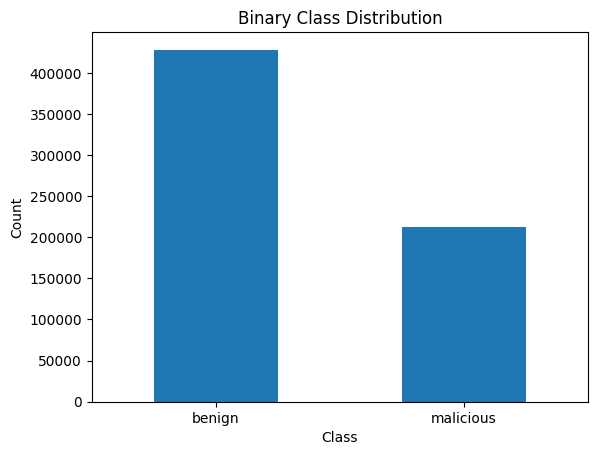

In [5]:
import matplotlib.pyplot as plt

class_counts.plot(kind="bar")
plt.title("Binary Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
# Split the data. 70% training, 15% validation, 15% test.
from sklearn.model_selection import train_test_split

X = df["url"]
y = df["binary_type"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 448737
Validation size: 96158
Test size: 96158


In [7]:
np.random.seed(42)
random.seed(42)

# **2. Baseline model**

In [8]:
# Extract features from raw urls
import re
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def extract_features(url):
  url = str(url)
  return {
      "url_length": len(url),
      "digit_count": sum(c.isdigit() for c in url),
      "dot_count": url.count("."),
      "slash_count": url.count("/"),
      "hyphen_count": url.count("-"),
      "underscore_count": url.count("_"),
      "question_count": url.count("?"),
      "equal_count": url.count("="),
      "ampersand_count": url.count("&"),
      "at_count": url.count("@"),
      "has_https": int("https" in url),
      "has_http": int("http" in url),
      "has_login": int("login" in url),
      "has_verify": int("verify" in url),
      "has_account": int("account" in url),
      "has_secure": int("secure" in url),
      "has_ip_pattern": int(bool(re.search(r"\d+\.\d+\.\d+\.\d+", url))),
    }

X_train_feat = pd.DataFrame([extract_features(u) for u in X_train])
X_val_feat = pd.DataFrame([extract_features(u) for u in X_val])
X_test_feat = pd.DataFrame([extract_features(u) for u in X_test])

X_train_feat.head()

,url_length,digit_count,dot_count,slash_count,hyphen_count,underscore_count,question_count,equal_count,ampersand_count,at_count,has_https,has_http,has_login,has_verify,has_account,has_secure,has_ip_pattern
0,56,0,2,2,0,4,0,0,0,0,0,0,0,0,0,0,0
1,100,21,3,6,3,0,1,3,2,0,0,0,0,0,0,0,0
2,110,18,2,3,11,0,0,0,0,0,0,1,0,0,0,0,0
3,107,6,1,4,13,0,0,0,0,0,0,0,0,0,0,0,0
4,41,9,1,3,1,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

print(label_encoder.classes_)

['benign' 'malicious']


In [10]:
def plot_confusion(y_true, y_pred, title, filename):
  cm = confusion_matrix(y_true, y_pred)
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels=label_encoder.classes_
      )
  fig, ax = plt.subplots(figsize=(5, 4))
  disp.plot(ax=ax, cmap="Blues", colorbar=False)
  plt.title(title)
  plt.tight_layout()
  plt.savefig(filename, dpi=300)
  plt.show()
  plt.close()

---- Baseline Validation ----
Accuracy: 0.856850184072048
Precision: 0.9000704039426208
Recall: 0.6402391311152149
F1: 0.7482395976223136
Confusion matrix:
[[61938  2271]
 [11494 20455]]

---- Baseline Test ----
Accuracy: 0.8576925476819401
Precision: 0.8996542820883112
Recall: 0.643463019186829
F1: 0.7502919708029198
Confusion matrix:
[[61916  2293]
 [11391 20558]]



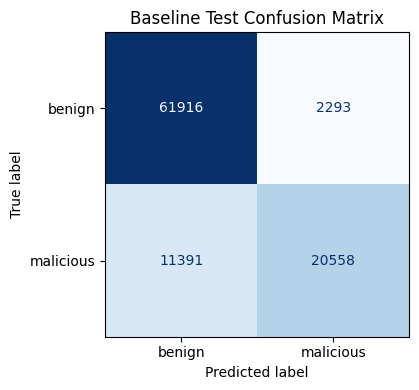

In [11]:
# train the model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_feat, y_train_enc)

# predict on validation and test
y_val_pred_base = baseline_model.predict(X_val_feat)
y_test_pred_base = baseline_model.predict(X_test_feat)

# evaluation
def print_metrics(y_true, y_pred, name):
  print("----", name, "----")
  print("Accuracy:", accuracy_score(y_true, y_pred))
  print("Precision:", precision_score(y_true, y_pred))
  print("Recall:", recall_score(y_true, y_pred))
  print("F1:", f1_score(y_true, y_pred))
  print("Confusion matrix:")
  print(confusion_matrix(y_true, y_pred))
  print()

print_metrics(y_val_enc, y_val_pred_base, "Baseline Validation")
print_metrics(y_test_enc, y_test_pred_base, "Baseline Test")

plot_confusion(y_test_enc, y_test_pred_base, "Baseline Test Confusion Matrix", "baseline_test_confusion.png")

In [12]:
baseline_results = pd.DataFrame({
    "url": X_test.reset_index(drop=True),
    "true_type": label_encoder.inverse_transform(y_test_enc),
    "pred_type": label_encoder.inverse_transform(y_test_pred_base)
})

print(baseline_results.sample(10, random_state=42))

baseline_results.to_csv("baseline_results_full.csv", index=False)
print("Saved: baseline_results_full.csv")

                                                     url  true_type  pred_type
87811                                      safecrypt.net  malicious     benign
4656   http://correios.com.br/para-governo/orgaos-de-...     benign     benign
60903  plasticoscarmen.com/wp-content/plugins/wordpre...     benign     benign
88252  alfa3444.net23.net/p/vaidevisa/asp/conta/auten...     benign     benign
74759                               flyingyogashala.com/     benign     benign
38370                    youtube.com/watch?v=dyhm4nj2ta0     benign     benign
7208   2719hyperion.com/2011/02/studio-geo-kansas-cit...     benign     benign
49142                    www.caulfei.demon.co.uk/zaurus/  malicious     benign
91281  https://onedrive.live.com/download?cid=c3d8ad8...  malicious  malicious
81944  sources.redhat.com/ml/cygwin/1997-09/msg00169....  malicious     benign
Saved: baseline_results_full.csv


# **3. Primary Model: Character-level CNN**

# 3.1 Basic Character-level CNN

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

tokenizer = Tokenizer(char_level=True, lower=True)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("Training shape:", X_train_pad.shape)

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

Vocabulary size: 268
Training shape: (448737, 200)


model definition

In [14]:
# CNN model
cnn_model = Sequential([
    tf.keras.Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len),
    Conv1D(filters=64, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 196, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,993 (82.00 KB)

 Trainable params: 20,993 (82.00 KB)

 Non-trainable params: 0 (0.00 B)

training

Epoch 1/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 234s 33ms/step - accuracy: 0.9636 - loss: 0.1082 - val_accuracy: 0.9758 - val_loss: 0.0720
Epoch 2/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 223s 32ms/step - accuracy: 0.9767 - loss: 0.0723 - val_accuracy: 0.9777 - val_loss: 0.0665
Epoch 3/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 267s 33ms/step - accuracy: 0.9794 - loss: 0.0640 - val_accuracy: 0.9789 - val_loss: 0.0622
Epoch 4/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 219s 31ms/step - accuracy: 0.9806 - loss: 0.0596 - val_accuracy: 0.9788 - val_loss: 0.0628
Epoch 5/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 261s 31ms/step - accuracy: 0.9815 - loss: 0.0566 - val_accuracy: 0.9794 - val_loss: 0.0602
3005/3005 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step
---- CNN Test ----
Accuracy: 0.9812496100168473
Precision: 0.9767824381603087
Recall: 0.9665404238004319
F1: 0.9716344414203232
Confusion matrix:
[[63475   734]
 [ 1069 30880]]



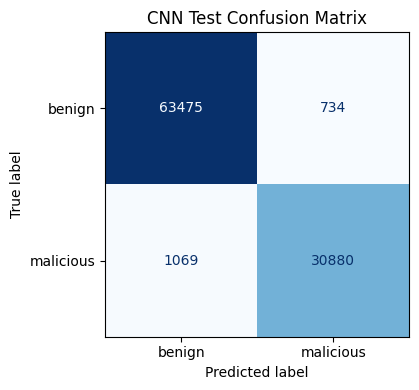

In [15]:
# training
history = cnn_model.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=64
)

# predict
y_test_prob_cnn = cnn_model.predict(X_test_pad)
y_test_pred_cnn = (y_test_prob_cnn > 0.5).astype(int).flatten()

# evaluate
print_metrics(y_test_enc, y_test_pred_cnn, "CNN Test")
plot_confusion(y_test_enc, y_test_pred_cnn, "CNN Test Confusion Matrix", "cnn_test_confusion.png")

evaluation

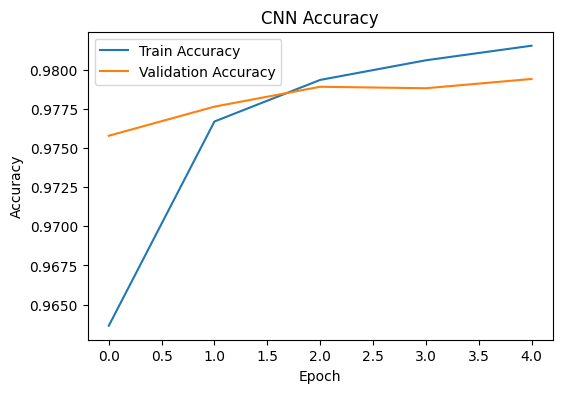

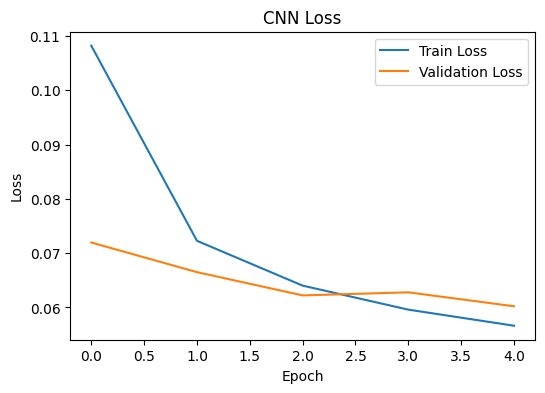

In [16]:
# accuracy curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# loss curve
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

analysis

In [17]:
cnn_results = pd.DataFrame({
    "url": X_test.reset_index(drop=True),
    "true_type": label_encoder.inverse_transform(y_test_enc),
    "pred_type": label_encoder.inverse_transform(y_test_pred_cnn)
})

print(cnn_results.sample(10, random_state=42))

                                                     url  true_type  pred_type
87811                                      safecrypt.net  malicious  malicious
4656   http://correios.com.br/para-governo/orgaos-de-...     benign     benign
60903  plasticoscarmen.com/wp-content/plugins/wordpre...     benign     benign
88252  alfa3444.net23.net/p/vaidevisa/asp/conta/auten...     benign     benign
74759                               flyingyogashala.com/     benign     benign
38370                    youtube.com/watch?v=dyhm4nj2ta0     benign     benign
7208   2719hyperion.com/2011/02/studio-geo-kansas-cit...     benign     benign
49142                    www.caulfei.demon.co.uk/zaurus/  malicious  malicious
91281  https://onedrive.live.com/download?cid=c3d8ad8...  malicious  malicious
81944  sources.redhat.com/ml/cygwin/1997-09/msg00169....  malicious     benign


In [18]:
# correct predictions
cnn_correct = cnn_results[cnn_results["true_type"] == cnn_results["pred_type"]]
print("Number of correct predictions:", len(cnn_correct))
print(cnn_correct.sample(5, random_state=42))

Number of correct predictions: 94355
                                                     url  true_type  pred_type
42143                        americancentury-global.com/     benign     benign
8953   marcosteacher.blogspot.com/2010/07/brasil-1-x-...     benign     benign
37761                                 free-gifts.h16.ru/     benign     benign
29469           reelectmayorfunkhouser.com/docs/meet.asp     benign     benign
32359  http://www.feilonline.com/index.php/component/...  malicious  malicious


In [19]:
# wrong predictions
cnn_wrong = cnn_results[cnn_results["true_type"] != cnn_results["pred_type"]]
print("Number of wrong predictions:", len(cnn_wrong))
print(cnn_wrong.sample(min(5, len(cnn_wrong)), random_state=42))

Number of wrong predictions: 1803
                                                     url  true_type  pred_type
43978                  web.onetel.net.uk/~richardweston/  malicious     benign
32733        web.mit.edu/tytso/www/pilot/prc-format.html  malicious     benign
84086                     savoiapower.com/biodiesel.html  malicious     benign
8713   en.wikipedia.org/wiki/electronic_article_surve...  malicious     benign
31899  academic.research.microsoft.com/author/2812189...     benign  malicious


# 3.2 Deeper Character-level CNN

model definition

In [20]:
improved_cnn = Sequential([
    tf.keras.Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=32),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    Conv1D(filters=64, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

improved_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 32)        │         8,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 196, 128)       │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 194, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,049 (226.75 KB)

 Trainable params: 58,049 (226.75 KB)

 Non-trainable params: 0 (0.00 B)

training

In [21]:
history_improved = improved_cnn.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=5,
    batch_size=64
)

Epoch 1/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 704s 100ms/step - accuracy: 0.9664 - loss: 0.0988 - val_accuracy: 0.9770 - val_loss: 0.0707
Epoch 2/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 747s 101ms/step - accuracy: 0.9805 - loss: 0.0612 - val_accuracy: 0.9823 - val_loss: 0.0550
Epoch 3/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 751s 102ms/step - accuracy: 0.9834 - loss: 0.0512 - val_accuracy: 0.9833 - val_loss: 0.0499
Epoch 4/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 712s 102ms/step - accuracy: 0.9852 - loss: 0.0454 - val_accuracy: 0.9842 - val_loss: 0.0484
Epoch 5/5
7012/7012 ━━━━━━━━━━━━━━━━━━━━ 737s 101ms/step - accuracy: 0.9865 - loss: 0.0408 - val_accuracy: 0.9841 - val_loss: 0.0489


3005/3005 ━━━━━━━━━━━━━━━━━━━━ 45s 15ms/step
---- Deeper CNN Test ----
Accuracy: 0.9852118388485618
Precision: 0.979999371049404
Recall: 0.9753982910263232
F1: 0.9776934178327163
Confusion matrix:
[[63573   636]
 [  786 31163]]



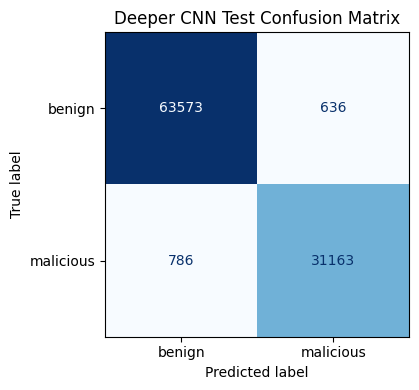

In [22]:
y_test_prob_improved = improved_cnn.predict(X_test_pad)
y_test_pred_improved = (y_test_prob_improved > 0.5).astype(int).flatten()

print_metrics(y_test_enc, y_test_pred_improved, "Deeper CNN Test")
plot_confusion(y_test_enc, y_test_pred_improved, "Deeper CNN Test Confusion Matrix", "improved_cnn_test_confusion.png")

In [23]:
improved_results = pd.DataFrame({
    "url": X_test.reset_index(drop=True),
    "true_type": label_encoder.inverse_transform(y_test_enc),
    "pred_type": label_encoder.inverse_transform(y_test_pred_improved)
})

improved_results.to_csv("improved_cnn_results_full.csv", index=False)
print("Saved: improved_cnn_results_full.csv")

Saved: improved_cnn_results_full.csv


evaluation

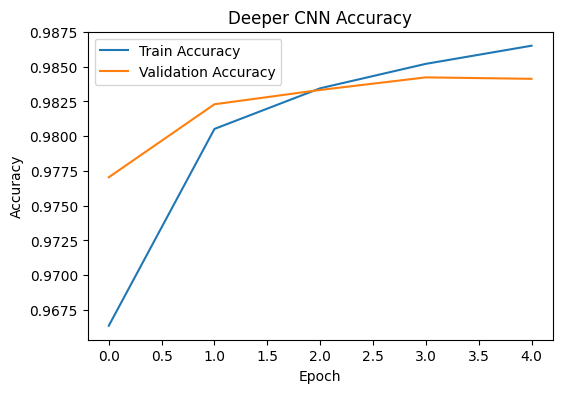

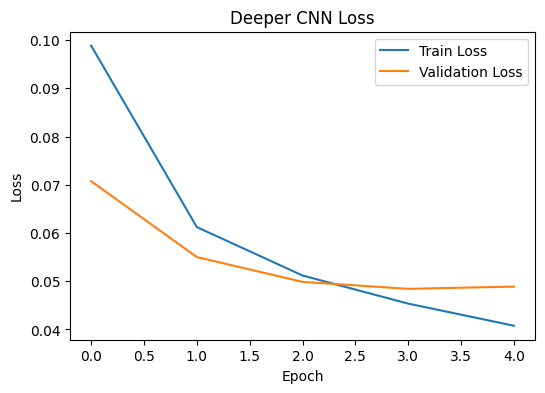

In [24]:
# accuracy curve
plt.figure(figsize=(6, 4))
plt.plot(history_improved.history["accuracy"], label="Train Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deeper CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# loss curve
plt.figure(figsize=(6, 4))
plt.plot(history_improved.history["loss"], label="Train Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("Deeper CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

analysis

In [25]:
print(improved_results.sample(10, random_state=42))

                                                     url  true_type  pred_type
87811                                      safecrypt.net  malicious  malicious
4656   http://correios.com.br/para-governo/orgaos-de-...     benign     benign
60903  plasticoscarmen.com/wp-content/plugins/wordpre...     benign     benign
88252  alfa3444.net23.net/p/vaidevisa/asp/conta/auten...     benign     benign
74759                               flyingyogashala.com/     benign     benign
38370                    youtube.com/watch?v=dyhm4nj2ta0     benign     benign
7208   2719hyperion.com/2011/02/studio-geo-kansas-cit...     benign     benign
49142                    www.caulfei.demon.co.uk/zaurus/  malicious  malicious
91281  https://onedrive.live.com/download?cid=c3d8ad8...  malicious  malicious
81944  sources.redhat.com/ml/cygwin/1997-09/msg00169....  malicious     benign


In [26]:
# correct predictions
improved_correct = improved_results[improved_results["true_type"] == improved_results["pred_type"]]
print("Number of correct predictions:", len(improved_correct))
print(improved_correct.sample(5, random_state=42))

Number of correct predictions: 94736
                                                     url  true_type  pred_type
24684  leobvp.com/xmlrpc/includes/http/customercard/d...     benign     benign
38332            aitchisondrillsnewzealand.blogspot.com/     benign     benign
69542  facebook.com/pages/sisters-of-st-joseph/108145...     benign     benign
58692  greenbiz.com/news/2009/12/03/iclei-usa-unveils...     benign     benign
11432  https://mitsui-jyuku.mixh.jp/uploads/97443fvas...  malicious  malicious


In [27]:
# wrong predictions
improved_wrong = improved_results[improved_results["true_type"] != improved_results["pred_type"]]
print("Number of wrong predictions:", len(improved_wrong))
print(improved_wrong.sample(min(5, len(improved_wrong)), random_state=42))

Number of wrong predictions: 1422
                                                     url  true_type  pred_type
5342                               steamgroups.net23.net     benign  malicious
73560  standards.iso.org/ittf/publiclyavailablestanda...  malicious     benign
42232  ww3.house.leg.state.mn.us/members/members.asp?...     benign  malicious
4187                       dlg.galileo.usg.edu/douglass/     benign  malicious
31272                                smartlanka.net/act/     benign  malicious


# **4. Model comparison and Summary**

We are using the deeper cnn as final cnn to compare with the baseline in this section

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Deeper Character-level CNN"],
    "Accuracy": [
        accuracy_score(y_test_enc, y_test_pred_base),
        accuracy_score(y_test_enc, y_test_pred_improved)
    ],
    "Precision": [
        precision_score(y_test_enc, y_test_pred_base),
        precision_score(y_test_enc, y_test_pred_improved)
    ],
    "Recall": [
        recall_score(y_test_enc, y_test_pred_base),
        recall_score(y_test_enc, y_test_pred_improved)
    ],
    "F1": [
        f1_score(y_test_enc, y_test_pred_base),
        f1_score(y_test_enc, y_test_pred_improved)
    ]
})

print(comparison_df)

                          Model  Accuracy  Precision    Recall        F1
0  Baseline Logistic Regression  0.857693   0.899654  0.643463  0.750292
1    Deeper Character-level CNN  0.985212   0.979999  0.975398  0.977693


In [29]:
# Summary

print("Total cleaned samples:", len(df))
print("\nBinary class counts:")
print(df["binary_type"].value_counts())

print("\nTrain / Validation / Test sizes:")
print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\n BASELINE TEST METRICS")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_base))
print("Precision:", precision_score(y_test_enc, y_test_pred_base))
print("Recall:", recall_score(y_test_enc, y_test_pred_base))
print("F1:", f1_score(y_test_enc, y_test_pred_base))

print("\n CNN TEST METRICS")
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_improved))
print("Precision:", precision_score(y_test_enc, y_test_pred_improved))
print("Recall:", recall_score(y_test_enc, y_test_pred_improved))
print("F1:", f1_score(y_test_enc, y_test_pred_improved))

print("\n CNN MODEL INFO")
print("Vocabulary size:", vocab_size)
print("Max URL length:", max_len)

Total cleaned samples: 641053

Binary class counts:
binary_type
benign       428059
malicious    212994
Name: count, dtype: int64

Train / Validation / Test sizes:
Train: 448737
Validation: 96158
Test: 96158

 BASELINE TEST METRICS
Accuracy: 0.8576925476819401
Precision: 0.8996542820883112
Recall: 0.643463019186829
F1: 0.7502919708029198

 CNN TEST METRICS
Accuracy: 0.9852118388485618
Precision: 0.979999371049404
Recall: 0.9753982910263232
F1: 0.9776934178327163

 CNN MODEL INFO
Vocabulary size: 268
Max URL length: 200


In [30]:
# save results
comparison_df.to_csv("final_model_comparison.csv", index=False)
print("Saved: final_model_comparison.csv")

cnn_results.to_csv("cnn_results_full.csv", index=False)
print("Saved: cnn_results_full.csv")

Saved: final_model_comparison.csv
Saved: cnn_results_full.csv


# **5. External New Data Evaluation**

This section evaluates the baseline model and the final selected CNN on an external URL dataset that was not part of the original train/validation/test split.

# 5.1 external data preparation

load data

In [41]:
external_file = "final_external_testing_dataset.csv"

external_raw = pd.read_csv(external_file)

print("Shape:", external_raw.shape)
print("Columns:", external_raw.columns.tolist())
external_raw.head()

Shape: (134, 2)
Columns: ['url', 'label']


,url,label
0,http://tinyurl.com/cmjl5ug,malicious
1,https://nationalpost.com/sponsored/life-sponso...,benign
2,https://apsc.ubc.ca/news/2025/ubc-led-internat...,benign
3,http://www.spg-pneus.com/skyfall/,malicious
4,http://www.bimmer-deals.com/,malicious


In [42]:
external_df = external_raw.iloc[:, :2].copy()
external_df.columns = ["url", "label"]

print(external_df.head())
print("\nRaw label counts:")
print(external_df["label"].value_counts(dropna=False))

                                                 url      label
0                         http://tinyurl.com/cmjl5ug  malicious
1  https://nationalpost.com/sponsored/life-sponso...     benign
2  https://apsc.ubc.ca/news/2025/ubc-led-internat...     benign
3                  http://www.spg-pneus.com/skyfall/  malicious
4                       http://www.bimmer-deals.com/  malicious

Raw label counts:
label
malicious    97
benign       37
Name: count, dtype: int64


Clean the dataset

In [43]:
external_df = external_df.dropna(subset=["url", "label"])
external_df["url"] = external_df["url"].astype(str).str.strip().str.lower()
external_df["label"] = external_df["label"].astype(str).str.strip().str.lower()

external_df = external_df[external_df["url"] != ""]
external_df = external_df.drop_duplicates(subset=["url"])

print("After cleaning:", external_df.shape)
print(external_df["label"].value_counts(dropna=False))
external_df.head()

After cleaning: (127, 2)
label
malicious    90
benign       37
Name: count, dtype: int64


,url,label
0,http://tinyurl.com/cmjl5ug,malicious
1,https://nationalpost.com/sponsored/life-sponso...,benign
2,https://apsc.ubc.ca/news/2025/ubc-led-internat...,benign
3,http://www.spg-pneus.com/skyfall/,malicious
4,http://www.bimmer-deals.com/,malicious


In [44]:
external_df = external_df[external_df["label"].isin(["benign", "malicious"])].copy()

print("Filtered shape:", external_df.shape)
print(external_df["label"].value_counts())

Filtered shape: (127, 2)
label
malicious    90
benign       37
Name: count, dtype: int64


Exclude the overlaps with the original dataset where the models were trained on

In [45]:
before_overlap = len(external_df)

external_df = external_df[~external_df["url"].isin(df["url"])].copy()

after_overlap = len(external_df)

print("Before overlap removal:", before_overlap)
print("After overlap removal:", after_overlap)
print("Removed overlaps:", before_overlap - after_overlap)
print(external_df["label"].value_counts())

Before overlap removal: 127
After overlap removal: 73
Removed overlaps: 54
label
benign       37
malicious    36
Name: count, dtype: int64


In [46]:
X_external = external_df["url"]
y_external = external_df["label"]
y_external_enc = label_encoder.transform(y_external)

print("External dataset ready.")
print("Total size:", len(X_external))

External dataset ready.
Total size: 73


# 5.2 Baseline evaluation on new data

---- Baseline External Data ----
Accuracy: 0.7123287671232876
Precision: 0.7272727272727273
Recall: 0.6666666666666666
F1: 0.6956521739130435
Confusion matrix:
[[28  9]
 [12 24]]



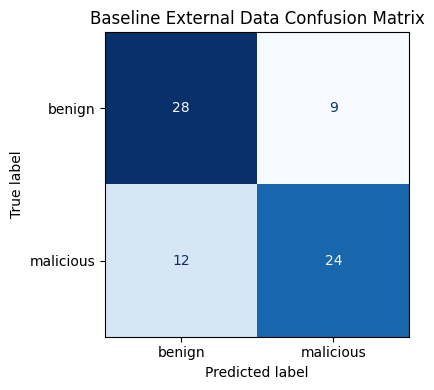

In [47]:
X_external_feat = pd.DataFrame([extract_features(u) for u in X_external])

y_external_pred_base = baseline_model.predict(X_external_feat)

print_metrics(y_external_enc, y_external_pred_base, "Baseline External Data")
plot_confusion(
    y_external_enc,
    y_external_pred_base,
    "Baseline External Data Confusion Matrix",
    "baseline_external_confusion.png"
)

# 5.3 Final CNN evaluation on new data

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
---- Final CNN External Data ----
Accuracy: 0.8904109589041096
Precision: 0.8181818181818182
Recall: 1.0
F1: 0.9
Confusion matrix:
[[29  8]
 [ 0 36]]



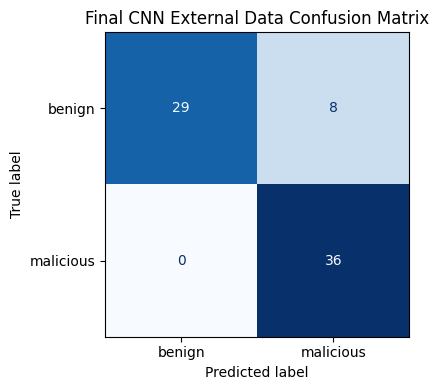

In [48]:
X_external_seq = tokenizer.texts_to_sequences(X_external)
X_external_pad = pad_sequences(
    X_external_seq,
    maxlen=max_len,
    padding="post",
    truncating="post"
)

y_external_prob_cnn = improved_cnn.predict(X_external_pad).flatten()
y_external_pred_cnn = (y_external_prob_cnn > 0.5).astype(int)

print_metrics(y_external_enc, y_external_pred_cnn, "Final CNN External Data")
plot_confusion(
    y_external_enc,
    y_external_pred_cnn,
    "Final CNN External Data Confusion Matrix",
    "final_cnn_external_confusion.png"
)

# 5.4 Compareson between the two methods on new data

In [50]:
external_comparison_df = pd.DataFrame({
    "Model": ["Baseline Logistic Regression", "Final Deeper CNN"],
    "Accuracy": [
        accuracy_score(y_external_enc, y_external_pred_base),
        accuracy_score(y_external_enc, y_external_pred_cnn)
    ],
    "Precision": [
        precision_score(y_external_enc, y_external_pred_base, zero_division=0),
        precision_score(y_external_enc, y_external_pred_cnn, zero_division=0)
    ],
    "Recall": [
        recall_score(y_external_enc, y_external_pred_base, zero_division=0),
        recall_score(y_external_enc, y_external_pred_cnn, zero_division=0)
    ],
    "F1": [
        f1_score(y_external_enc, y_external_pred_base, zero_division=0),
        f1_score(y_external_enc, y_external_pred_cnn, zero_division=0)
    ]
})

print(external_comparison_df)
external_comparison_df.to_csv("external_model_comparison.csv", index=False)
print("Saved: external_model_comparison.csv")

                          Model  Accuracy  Precision    Recall        F1
0  Baseline Logistic Regression  0.712329   0.727273  0.666667  0.695652
1              Final Deeper CNN  0.890411   0.818182  1.000000  0.900000
Saved: external_model_comparison.csv
